In [2]:
# impoting the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import svm
import xgboost

Matplotlib is building the font cache; this may take a moment.


In [3]:

# Change the path to your file
data = pd.read_csv("traffic volume.csv")

# Now the 'data' variable contains the content of the CSV file located at the provided path


In [4]:
data

,holiday,temp,rain,snow,weather,date,Time,traffic_volume
0,NaN,288.28,0.0,0.0,Clouds,02-10-2012,09:00:00,5545
1,NaN,289.36,0.0,0.0,Clouds,02-10-2012,10:00:00,4516
2,NaN,289.58,0.0,0.0,Clouds,02-10-2012,11:00:00,4767
3,NaN,290.13,0.0,0.0,Clouds,02-10-2012,12:00:00,5026
4,NaN,291.14,0.0,0.0,Clouds,02-10-2012,13:00:00,4918
...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,Clouds,30-09-2018,19:00:00,3543
48200,NaN,282.76,0.0,0.0,Clouds,30-09-2018,20:00:00,2781
48201,NaN,282.73,0.0,0.0,Thunderstorm,30-09-2018,21:00:00,2159
48202,NaN,282.09,0.0,0.0,Clouds,30-09-2018,22:00:00,1450


In [5]:
data.head()

,holiday,temp,rain,snow,weather,date,Time,traffic_volume
0,NaN,288.28,0.0,0.0,Clouds,02-10-2012,09:00:00,5545
1,NaN,289.36,0.0,0.0,Clouds,02-10-2012,10:00:00,4516
2,NaN,289.58,0.0,0.0,Clouds,02-10-2012,11:00:00,4767
3,NaN,290.13,0.0,0.0,Clouds,02-10-2012,12:00:00,5026
4,NaN,291.14,0.0,0.0,Clouds,02-10-2012,13:00:00,4918


In [6]:
data.tail()

,holiday,temp,rain,snow,weather,date,Time,traffic_volume
48199,NaN,283.45,0.0,0.0,Clouds,30-09-2018,19:00:00,3543
48200,NaN,282.76,0.0,0.0,Clouds,30-09-2018,20:00:00,2781
48201,NaN,282.73,0.0,0.0,Thunderstorm,30-09-2018,21:00:00,2159
48202,NaN,282.09,0.0,0.0,Clouds,30-09-2018,22:00:00,1450
48203,NaN,282.12,0.0,0.0,Clouds,30-09-2018,23:00:00,954


In [7]:
data.shape

(48204, 8)

In [8]:
data.describe()

,temp,rain,snow,traffic_volume
count,48151.000000,48202.000000,48192.000000,48204.000000
mean,281.205351,0.334278,0.000222,3259.818355
std,13.343675,44.790062,0.008169,1986.860670
min,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1193.000000
50%,282.460000,0.000000,0.000000,3380.000000
75%,291.810000,0.000000,0.000000,4933.000000
max,310.070000,9831.300000,0.510000,7280.000000


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   holiday         61 non-null     str    
 1   temp            48151 non-null  float64
 2   rain            48202 non-null  float64
 3   snow            48192 non-null  float64
 4   weather         48155 non-null  str    
 5   date            48204 non-null  str    
 6   Time            48204 non-null  str    
 7   traffic_volume  48204 non-null  int64  
dtypes: float64(3), int64(1), str(4)
memory usage: 2.9 MB


In [10]:
data.dtypes

holiday               str
temp              float64
rain              float64
snow              float64
weather               str
date                  str
Time                  str
traffic_volume      int64
dtype: object

In [11]:
from collections import Counter
print(Counter(data['rain']))
print(Counter(data['snow']))

Counter({0.0: 44735, 0.25: 948, 0.51: 256, 1.02: 123, 0.3: 121, 0.76: 109, 0.38: 99, 1.78: 91, 1.52: 69, 0.64: 55, 1.27: 50, 0.6: 32, 2.79: 29, 0.44: 26, 0.89: 25, 2.54: 23, 0.28: 23, 0.42: 21, 1.4: 21, 0.34: 20, 2.16: 19, 2.29: 19, 2.03: 19, 1.8: 16, 1.09: 16, 3.05: 15, 0.32: 15, 1.2: 15, 0.9: 15, 0.98: 14, 0.68: 13, 0.81: 13, 4.57: 13, 7.11: 12, 0.85: 12, 0.7: 11, 2.1: 11, 0.55: 11, 5.59: 10, 1.86: 10, 8.4: 10, 1.15: 10, 0.47: 9, 5.08: 9, 1.21: 9, 0.43: 9, 6.1: 9, 5.84: 8, 1.66: 8, 0.79: 8, 0.4: 8, 1.14: 8, 2.2: 8, 1.85: 8, 2.41: 8, 3.3: 8, 1.41: 7, 6.6: 7, 0.35: 7, 1.91: 7, 0.52: 7, 1.3: 7, 0.8: 7, 0.66: 7, 2.67: 7, 1.33: 7, 1.1: 7, 4.06: 7, 0.57: 6, 0.29: 6, 0.36: 6, 1.0: 6, 1.44: 6, 8.64: 6, 1.35: 6, 5.97: 6, 0.56: 6, 0.91: 6, 0.54: 6, 0.94: 6, 0.96: 6, 2.86: 6, 0.78: 6, 2.22: 6, 6.35: 6, 4.89: 6, 0.93: 6, 3.13: 6, 0.63: 6, 2.62: 6, 1.6: 6, 4.74: 6, 2.76: 6, 3.45: 6, 0.69: 5, 3.18: 5, 0.61: 5, 5.42: 5, 1.39: 5, 0.53: 5, 0.48: 5, 0.59: 5, 0.71: 5, 0.27: 5, 2.85: 5, 0.65: 5, 1.5: 5,

In [37]:
data['temp'] = data['temp'].fillna(data['temp'].mean())
data['rain'] = data['rain'].fillna(data['rain'].mean())
data['snow'] = data['snow'].fillna(data['snow'].mean())

In [38]:
# Check for missing values
print(data.isna().sum())

holiday           0
temp              0
rain              0
snow              0
weather           0
traffic_volume    0
day               0
month             0
year              0
hours             0
minutes           0
seconds           0
dtype: int64


In [13]:
print(Counter(data['weather']))

Counter({'Clouds': 15144, 'Clear': 13383, 'Mist': 5942, 'Rain': 5665, 'Snow': 2875, 'Drizzle': 1818, 'Haze': 1359, 'Thunderstorm': 1033, 'Fog': 912, nan: 49, 'Smoke': 20, 'Squall': 4})


In [14]:
data['weather'].fillna('Clouds',inplace=True)

C:\Users\dilee\AppData\Local\Temp\ipykernel_13276\1731991201.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['weather'].fillna('Clouds',inplace=True)


0              Clouds
1              Clouds
2              Clouds
3              Clouds
4              Clouds
             ...     
48199          Clouds
48200          Clouds
48201    Thunderstorm
48202          Clouds
48203          Clouds
Name: weather, Length: 48204, dtype: str

In [15]:
data.isnull().sum()

holiday           48143
temp                 53
rain                  2
snow                 12
weather              49
date                  0
Time                  0
traffic_volume        0
dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['weather']=le.fit_transform(data['weather'])
data['holiday']=le.fit_transform(data['holiday'])

In [17]:
data.head()

,holiday,temp,rain,snow,weather,date,Time,traffic_volume
0,11,288.28,0.0,0.0,1,02-10-2012,09:00:00,5545
1,11,289.36,0.0,0.0,1,02-10-2012,10:00:00,4516
2,11,289.58,0.0,0.0,1,02-10-2012,11:00:00,4767
3,11,290.13,0.0,0.0,1,02-10-2012,12:00:00,5026
4,11,291.14,0.0,0.0,1,02-10-2012,13:00:00,4918


In [18]:
#splitting the date column into year,month,day
data[["day", "month", "year"]] =data["date"].str.split("-",expand = True)

In [19]:
#splitting the date column into year,month,day
data[["hours", "minutes", "seconds"]]=data["Time"].str.split(":",expand =True)

In [21]:
data.drop(columns=['date', 'Time'], inplace=True)

In [ ]:
data.head()

,holiday,temp,rain,snow,weather,traffic_volume,day,month,year,hours,minutes,seconds
0,7,288.28,0.0,0.0,1,5545,02,10,2012,09,00,00
1,7,289.36,0.0,0.0,1,4516,02,10,2012,10,00,00
2,7,289.58,0.0,0.0,1,4767,02,10,2012,11,00,00
3,7,290.13,0.0,0.0,1,5026,02,10,2012,12,00,00
4,7,291.14,0.0,0.0,1,4918,02,10,2012,13,00,00


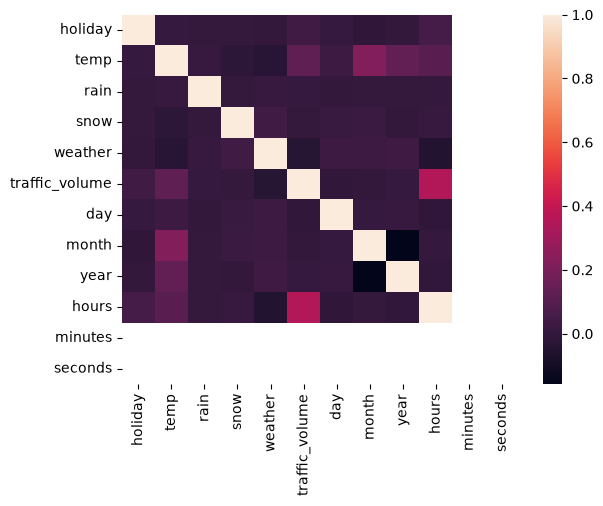

In [22]:
import seaborn as sns
dataplot=sns.heatmap(data.corr())

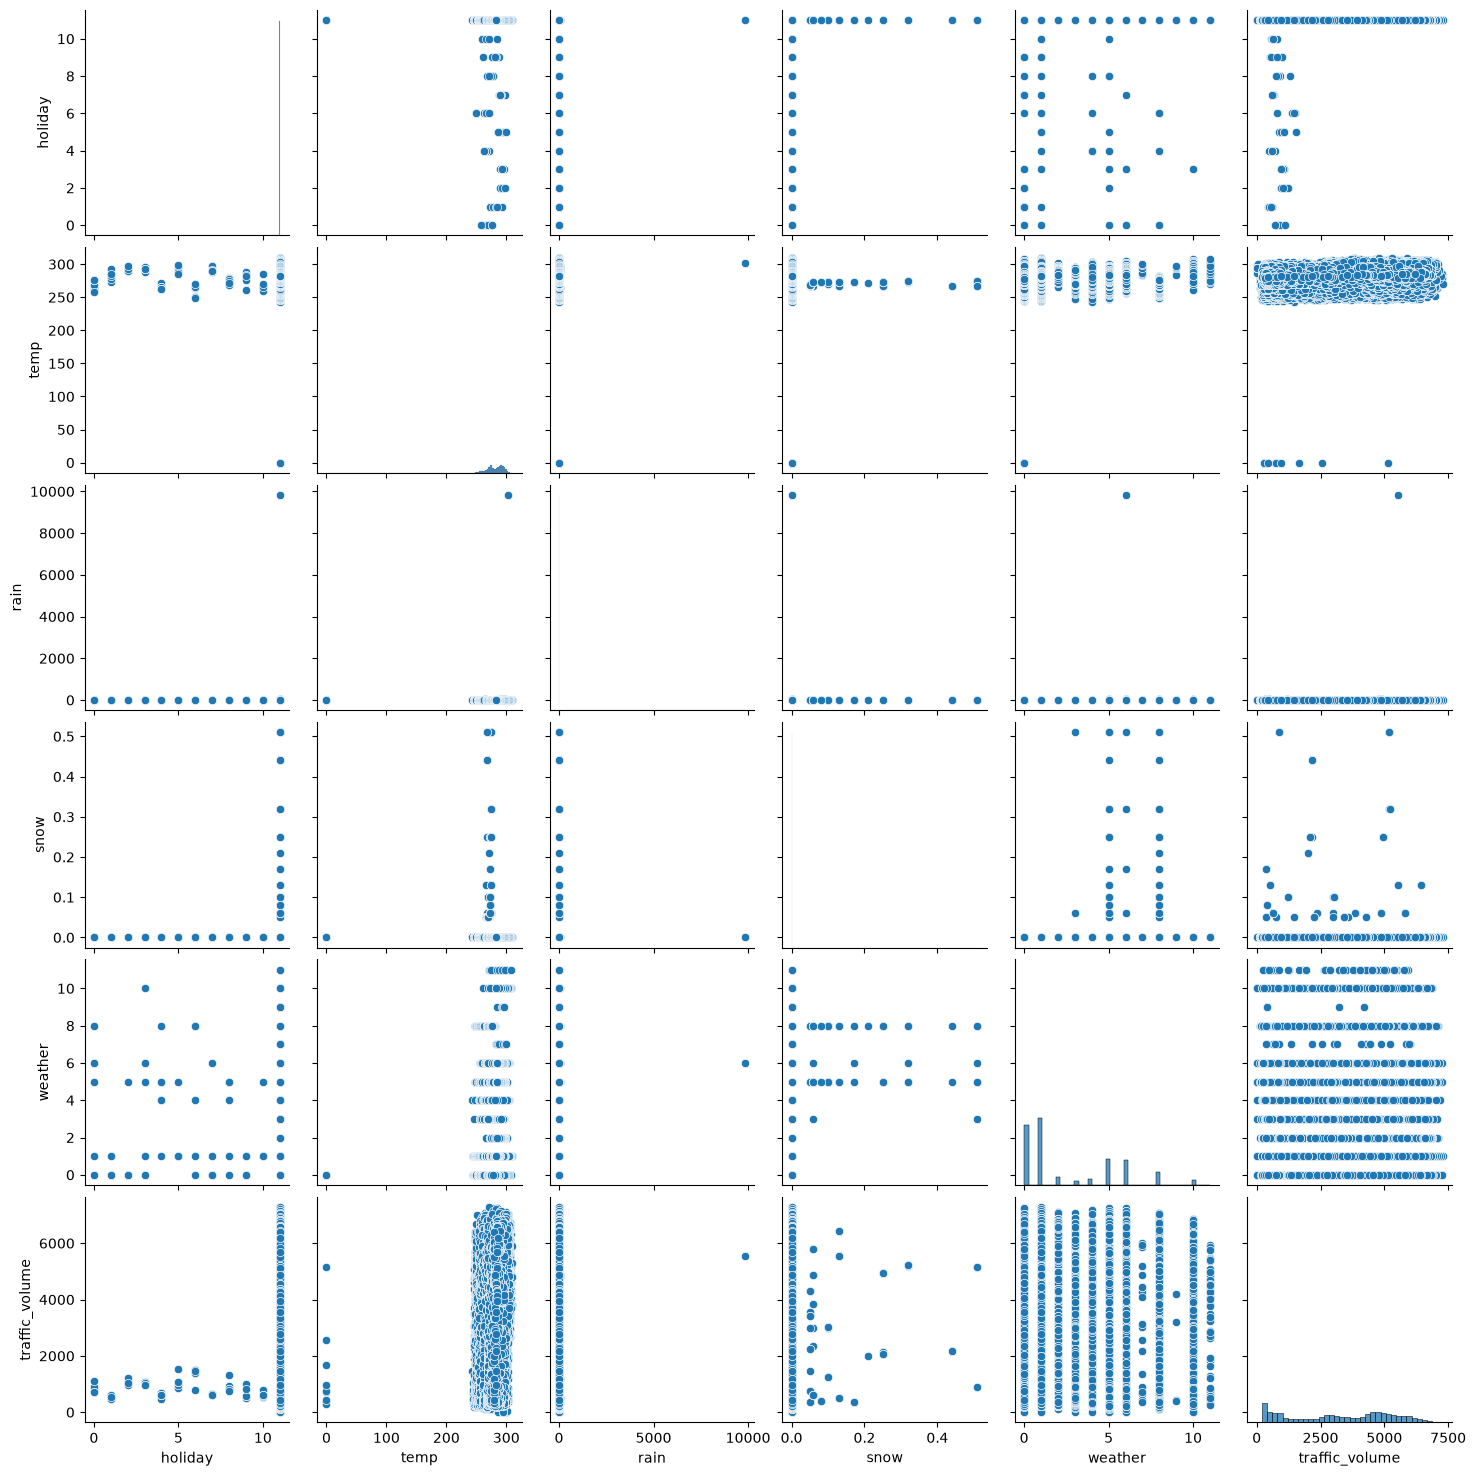

In [23]:
sns.pairplot(data)

<Axes: >

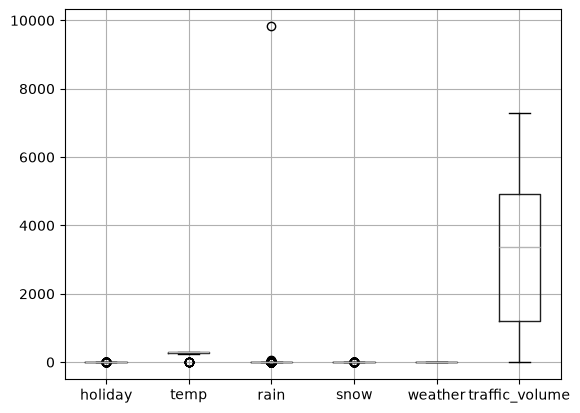

In [24]:
data.boxplot()

In [25]:
data.head()

,holiday,temp,rain,snow,weather,traffic_volume,day,month,year,hours,minutes,seconds
0,11,288.28,0.0,0.0,1,5545,02,10,2012,09,00,00
1,11,289.36,0.0,0.0,1,4516,02,10,2012,10,00,00
2,11,289.58,0.0,0.0,1,4767,02,10,2012,11,00,00
3,11,290.13,0.0,0.0,1,5026,02,10,2012,12,00,00
4,11,291.14,0.0,0.0,1,4918,02,10,2012,13,00,00


# Splitting The Dataset Into Dependent And Independent Variable

In [39]:
y= data['traffic_volume']
x = data.drop(columns=['traffic_volume'])
x.shape
y.shape

(48204,)

# Feature Scaling

In [28]:
names=x.columns

In [29]:
from sklearn.preprocessing import scale

In [30]:
x=scale(x)

In [31]:
x=pd.DataFrame( x,columns=names)

In [32]:
x.head()

,holiday,temp,rain,snow,weather,day,month,year,hours,minutes,seconds
0,0.031687,0.530193,-0.007463,-0.027232,-0.567564,-1.574903,1.02758,-1.855294,-0.345548,0.0,0.0
1,0.031687,0.611131,-0.007463,-0.027232,-0.567564,-1.574903,1.02758,-1.855294,-0.201459,0.0,0.0
2,0.031687,0.627618,-0.007463,-0.027232,-0.567564,-1.574903,1.02758,-1.855294,-0.057371,0.0,0.0
3,0.031687,0.668837,-0.007463,-0.027232,-0.567564,-1.574903,1.02758,-1.855294,0.086718,0.0,0.0
4,0.031687,0.744529,-0.007463,-0.027232,-0.567564,-1.574903,1.02758,-1.855294,0.230807,0.0,0.0


#           Splitting The Data Into Train And Test

In [40]:
from sklearn.model_selection import train_test_split
# Assuming you have 'x' as your independent variables and 'y' as your dependent variable
# Split the dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [41]:
print("X Train:", x_train.shape)
print("X Test :", x_test.shape)
print("Y Train:", y_train.shape)
print("Y Test :", y_test.shape)

X Train: (38563, 11)
X Test : (9641, 11)
Y Train: (38563,)
Y Test : (9641,)


# *MODEL BUILDING*

TRAINING AND TESTING THE MODEL

In [34]:
#initialize the model
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import svm
import xgboost

In [42]:

# Create and train the models
lin_reg=linear_model.LinearRegression()
Dtree=tree.DecisionTreeRegressor()
Rand = ensemble.RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
svr=svm.SVR()
XGB=xgboost.XGBRegressor()

In [43]:
#fit models with x_train and y_train
lin_reg.fit(x_train, y_train)
Dtree.fit(x_train, y_train)
Rand.fit(x_train, y_train)
svr.fit(x_train, y_train)
XGB.fit(x_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:day: str, month: str, year: str, hours: str, minutes: str, seconds: str

In [44]:
print("Random Forest trained:", hasattr(Rand, "estimators_"))
print("Number of trees:", len(Rand.estimators_) if hasattr(Rand, "estimators_") else "Not trained")

Random Forest trained: True
Number of trees: 50


In [45]:
import joblib

joblib.dump(Rand, "model.pkl")

print("model.pkl saved successfully.")

model.pkl saved successfully.


In [ ]:
p1=lin_reg.predict (x_train)
p2=Dtree.predict(x_train)
p3=Rand.predict(x_train)
p4=svr.predict(x_train)
p5=XGB.predict(x_train)

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:192: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


In [46]:
prediction = Rand.predict(x_test)

print("First 10 predictions:")
print(prediction[:10])

print("\nActual values:")
print(y_test.iloc[:10].values)

First 10 predictions:
[4715.00285676 2574.7997619   551.84655556 5587.84777181  650.01255411
 1895.00340665 4224.41854363 2824.83380159 3999.31909524 4338.19910911]

Actual values:
[5875 2868  557 4354  783 1990 4481 2971 3890 4545]


# Model Evalution

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("Random Forest Model Evaluation")
print("------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest Model Evaluation
------------------------------
MAE : 528.5872846433728
RMSE: 818.8275636947477
R²  : 0.8285555681763614


In [48]:
import joblib

test_model = joblib.load("model.pkl")

test_prediction = test_model.predict(x_test)

print("Model loaded successfully.")
print("Test prediction:", test_prediction[:5])

Model loaded successfully.
Test prediction: [4715.00285676 2574.7997619   551.84655556 5587.84777181  650.01255411]


In [ ]:
from sklearn import metrics


In [ ]:
print(metrics.r2_score(p1,y_train))
print(metrics.r2_score(p2,y_train))
print(metrics.r2_score(p3,y_train))
print(metrics.r2_score(p4,y_train))
print(metrics.r2_score(p5,y_train))

-5.5171896462675925
1.0
0.9749775062433306
-12.166100834968676
0.8427046230488833


# **Testing data finding r-score**

In [ ]:
p1=lin_reg.predict(x_test)
p2=Dtree.predict(x_test)
p3=Rand.predict(x_test)
p4=svr.predict(x_test)
p5=XGB.predict(x_test)

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\data.py:192: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


In [ ]:
print(metrics.r2_score(p1,y_test))
print(metrics.r2_score(p2,y_test))
print(metrics.r2_score(p3,y_test))
print(metrics.r2_score(p4,y_test))
print(metrics.r2_score(p5,y_test))

-5.399136170612289
0.6880678200058779
0.8049737220564742
-11.949572288463273
0.8014488205115124


# Randforest gives r-score

In [ ]:
MSE=metrics.mean_squared_error(p3,y_test)

In [ ]:
np.sqrt(MSE)

795.2435684492522

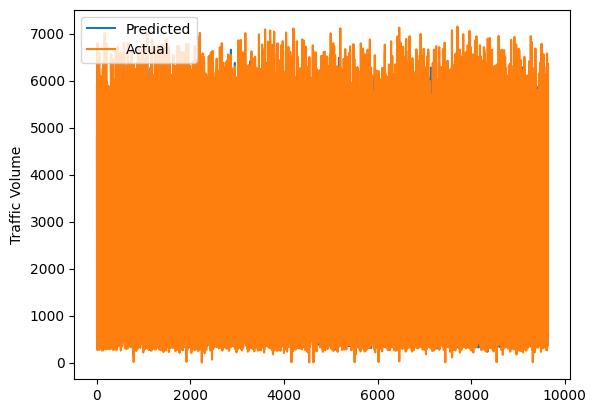

In [ ]:
# plotting the graph for the actual and predicted values
import matplotlib.pyplot as plt
plt.plot(p3, label='Predicted')
plt.plot(y_test.values, label='Actual')
plt.ylabel('Traffic Volume')
plt.legend()
plt.show()

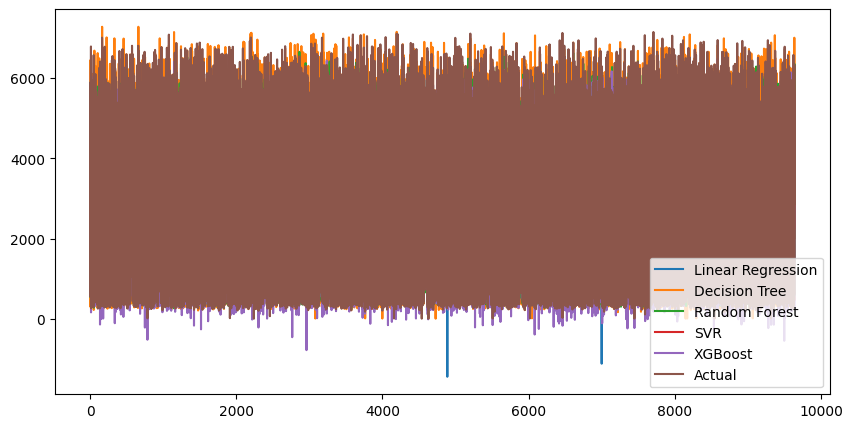

In [ ]:
#comparion graph of various models
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(p1,label='Linear Regression')
plt.plot(p2,label='Decision Tree')
plt.plot(p3,label='Random Forest')
plt.plot(p4,label='SVR')
plt.plot(p5,label='XGBoost')
plt.plot(y_test.values,label='Actual')
plt.legend()
plt.show()

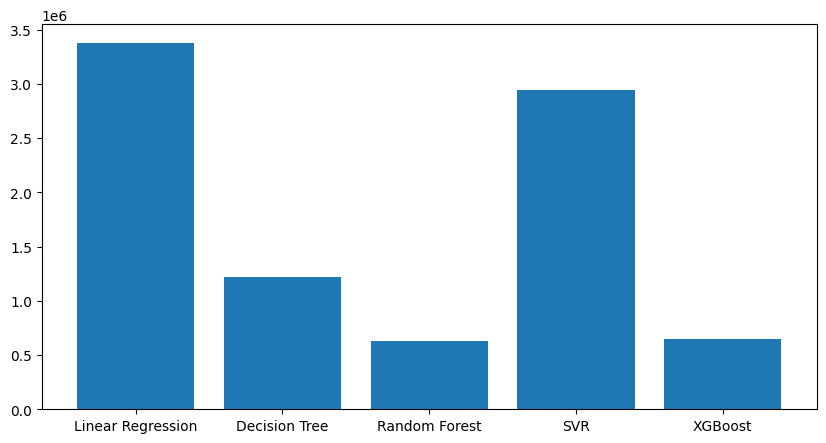

In [ ]:
#bar plots of rmse valyes of various models
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(['Linear Regression','Decision Tree','Random Forest','SVR','XGBoost'],[metrics.mean_squared_error(p1,y_test),metrics.mean_squared_error(p2,y_test),metrics.mean_squared_error(p3,y_test),metrics.mean_squared_error(p4,y_test),metrics.mean_squared_error(p5,y_test)])
plt.show()

# SAVING MODEL

In [ ]:
import pickle

In [ ]:
pickle.dump(Rand,open("model.pkl",'wb'))
pickle.dump(le,open("encoder.pkl",'wb'))

In [ ]:
data.head()

,holiday,temp,rain,snow,weather,traffic_volume,day,month,year,hours,minutes,seconds
0,7,288.28,0.0,0.0,1,5545,02,10,2012,09,00,00
1,7,289.36,0.0,0.0,1,4516,02,10,2012,10,00,00
2,7,289.58,0.0,0.0,1,4767,02,10,2012,11,00,00
3,7,290.13,0.0,0.0,1,5026,02,10,2012,12,00,00
4,7,291.14,0.0,0.0,1,4918,02,10,2012,13,00,00
